# Integrantes

* Centeno Amado Eduardo
* Orozpe Frias Erick Adrian
* Pineda Gaona Maricruz
* Rodriguez Teodores Armando
* Velasco Martell Dayra

# Librerías

In [1]:
# Sistema
import os

# Análisis y manipulación de datos
import numpy as np
import pandas as pd

from scipy.stats import uniform

# Manejo de texto plano
import re
import emoji
import unicodedata

# Nube de palabras
from wordcloud import WordCloud, STOPWORDS

# Análisis de texto
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo de regresión logítica y Bayes
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Búsqueda de hiper-parámetros, train test, métricas
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, make_scorer, mean_squared_error, mean_absolute_error
from sklearn.svm import LinearSVC, SVR

# Guardar modelo y pipeline
import pickle
from sklearn.pipeline import make_pipeline

#Graficas

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pandas.plotting import andrews_curves

# IMDB Reviews — Clasificación de reseñas

* Realiza **análisis de texto** para posteriormente **clasificar reseñas** de IMDB.
* **Datos**: descarga el dataset desde [https://ai.stanford.edu/~amaas/data/sentiment/](https://ai.stanford.edu/~amaas/data/sentiment/).
* Las reseñas ya están **divididas en train/test**; encuentra la forma de **leerlas**.
* **Modelos a comparar**:

  * Clasificador **bayesiano**,
  * **Regresión logística**,
  * **SVM** con **kernel lineal**,
    y selecciona el **mejor modelo**.
* **Nota**: si procesas texto con **spaCy**, puede tardar por el volumen de datos; considera dejar esos pasos corriendo mientras haces otras actividades.

## Tratamiento de Datos

In [41]:
root = "../Datasets/aclImdb"   # <- adjust to your local path

rows = []
for dirpath, dirnames, filenames in os.walk(root):
    # Expect paths like .../aclImdb/train/pos/xxxxx_7.txt
    parts = dirpath.split(os.sep)
    if len(parts) < 2: 
        continue

    split = "train" if "train" in parts else ("test" if "test" in parts else None)
    label = 1 if "pos" in parts else (0 if "neg" in parts else None)
    if split is None or label is None:
        continue  # skip e.g. unsup and other folders

    for fn in filenames:
        if not fn.endswith(".txt"):
            continue
        # filename pattern: "<id>_<rating>.txt"
        stem = fn[:-4]
        if "_" not in stem:
            continue
        id_str, rating_str = stem.split("_", 1)
        path = os.path.join(dirpath, fn)
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read().replace("<br />", " ")
        rows.append({
            #"path": path,
            "split": split, # train | test
            "label": label, # 1 pos | 0 neg
            "text": text,
            "rating": int(rating_str),
            "id": int(id_str)
        })

df = pd.DataFrame(rows)

display(df.head())
print(df.shape)

,split,label,text,rating,id
0,train,1,The Running Man is one of those films that if ...,7,5349
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419
3,train,1,Something happens to Sondra Pransky when she e...,8,11951
4,train,1,I had never heard of this film prior to seeing...,7,9370


(50000, 5)


**Run In Terminal**

`pip install -U spacy`

`python -m spacy download en_core_web_sm`

In [73]:
nlp = spacy.load("en_core_web_sm")
stop_words = nlp.Defaults.stop_words

In [83]:
print(list(stop_words)[:10])

['get', 'otherwise', 'thereby', 'these', 'how', 'hundred', 'did', 'sometime', 'his', 'serious']


In [84]:
def clean_text(s: str) -> str:
    s = s.replace("<br />", " ")                  # remove HTML line breaks
    s = re.sub(r"<[^>]+>", " ", s)                # just in case, drop any other tags
    s = re.sub(r"\s+", " ", s).strip()            # normalize whitespace
    s = s.lower()
    doc = nlp(s)

    #Filtrar tokens válidos
    tokens = [
        token.lemma_
        for token in doc
            if not token.is_stop          # remove stopwords
            and not token.is_punct        # remove punctuation
            and token.is_alpha            # keep short words
            and len(token) > 2            # evitar tokens muy cortos
    ]
    
    return tokens if tokens else None

In [85]:
df['text_clean'] = df['text'].map(clean_text)

In [89]:
df.rename(columns={'text_clean': 'tokens'}, inplace=True)

In [99]:
# Eliminar filas sin tokens

if df['tokens'].isna().sum() > 0:
    df = df.dropna(subset=["tokens"]).reset_index(drop=True)
else:
    print("NO hay valores nulos.")

NO hay valores nulos.


In [105]:
if df['tokens'].apply(lambda x: len(x) == 0).sum() > 0:
    df = df.loc[df['tokens'].apply(lambda x: len(x) > 0)]
else:
    print('NO hay tokens vacíos.')

NO hay tokens vacíos.


In [107]:
# Definimos una lista de todas las palabras

all_words = [word for tokens in df["tokens"] for word in tokens]
freq = Counter(all_words)

In [115]:
# Definimos los hapaxes (palabras que solo aparecen 1 vez)

hapaxes = {word: count for word, count in freq.items() if count == 1}

In [111]:
# Función para eliminar hapaxes

def remove_hapaxes(tokens):
    global hapaxes
    return [t for t in tokens if t not in hapaxes]

In [117]:
tokens_copy = df['tokens'].copy() # Respaldo

In [127]:
df['tokens'] = tokens_copy.map(remove_hapaxes)

In [128]:
df.columns

Index(['split', 'label', 'text', 'rating', 'id', 'tokens'], dtype='object')

In [129]:
# Crear columna de texto limpio (para WordCloud y TF-IDF)

df["text_clean"] = df["tokens"].apply(lambda x: " ".join(x))

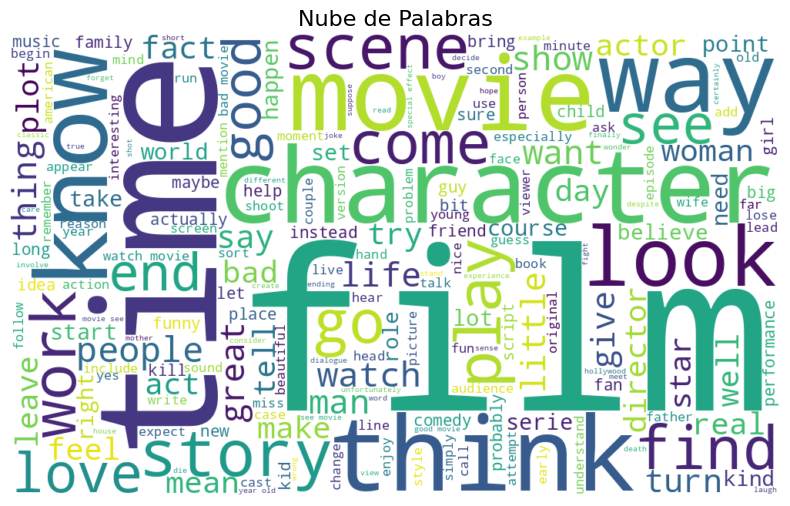

In [133]:
# Nos saltamos el paso de normalizar porque en inglés no existen los acentos

texto_total = " ".join(df["text_clean"].tolist())

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis"
).generate(texto_total)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras", fontsize=16)
plt.show()

In [134]:
df.head()

,split,label,text,rating,id,tokens,text_clean
0,train,1,The Running Man is one of those films that if ...,7,5349,"[run, man, film, overwatche, boring, depressin...",run man film overwatche boring depressing advi...
1,train,1,"This is a great, ridiculous horror movie that ...",9,5973,"[great, ridiculous, horror, movie, capture, es...",great ridiculous horror movie capture essence ...
2,train,1,"I have to agree with MR. Caruso Jr Lanza,s was...",10,10419,"[agree, caruso, lanza, fine, voice, god, offer...",agree caruso lanza fine voice god offer find c...
3,train,1,Something happens to Sondra Pransky when she e...,8,11951,"[happen, sondra, pransky, enter, magician, box...",happen sondra pransky enter magician box stage...
4,train,1,I had never heard of this film prior to seeing...,7,9370,"[hear, film, prior, see, wonder, independent, ...",hear film prior see wonder independent film co...


In [140]:
X_train = df.loc[df["split"]=="train", "text_clean"]
y_train = df.loc[df["split"]=="train", "label"]

X_test  = df.loc[df["split"]=="test",  "text_clean"]
y_test  = df.loc[df["split"]=="test",  "label"]

In [153]:
# Vectorizamos

"""tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df= 0.001,
    max_df=0.7,
    stop_words=None
)"""

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=None,
    lowercase=False,        # ya se hizo .lower()
    stop_words=None,        # ya no hay stopwords
    strip_accents="unicode",
    sublinear_tf=True,
    dtype=np.float32
)

In [154]:
# Ajustamos con el train y transformamos ambos

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [155]:
print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (25000, 78113)
Test shape:  (25000, 78113)


## Bayes Classifier

In [199]:
def evaluate_model(model, X, y, dataset_name="Dataset"):
    # 1) Obtener "scores" y umbral por defecto según el tipo de modelo
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)[:, 1]
        default_thr = 0.5
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        default_thr = 0.0          # frontera de decisión en SVM lineal
    else:
        # fallback mínimo: solo métricas con predicción discreta
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)
        acc = accuracy_score(y, y_pred)
        sens = recall_score(y, y_pred)
        spec = cm[0,0] / (cm[0,0] + cm[0,1])
        print(f"\n=== Resultados en {dataset_name} (sin scores) ===")
        print(f"Accuracy: {acc:.4f}  Sens: {sens:.4f}  Esp: {spec:.4f}")
        print("AUC/ROC no disponible (el modelo no da scores).")
        return

    # 2) Métricas con umbral por defecto
    y_pred_default = (scores >= default_thr).astype(int)
    cm = confusion_matrix(y, y_pred_default)
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, scores)

    print(f"\n=== Resultados en {dataset_name} (umbral = {default_thr:.2f}) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")

    # 3) Umbral óptimo (Youden J) + curva ROC
    fpr, tpr, thresholds = roc_curve(y, scores)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:        {best_threshold:.4f}")
    print(f"Sensibilidad óptima:  {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima: {specificity[idx_opt]:.4f}")

    # 4) Métricas con umbral óptimo
    y_pred_opt = (scores >= best_threshold).astype(int)
    cm_opt = confusion_matrix(y, y_pred_opt)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")

    # 5) Curva ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})")
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend(); plt.show()

In [160]:
# Creamos un grid para el mejor alpha
param_grid = {"alpha": np.logspace(-3, 1, 10)}  # valores desde 0.001 hasta 10
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

,estimator,MultinomialNB()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.46415888336127775


In [161]:
best_alpha = grid.best_params_["alpha"]
print(f"Mejor alfa encontrado: {best_alpha:.4f}")

Mejor alfa encontrado: 0.4642


In [162]:
# Modelo final
nb = MultinomialNB(alpha=best_alpha)
nb.fit(X_train_tfidf, y_train)

,alpha,0.46415888336127775
,force_alpha,True
,fit_prior,True
,class_prior,None


In [163]:
 #Validación cruzada
cv_scores = cross_val_score(nb, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8751
Mediana: 0.8762
Desviación estándar: 0.0022



=== Resultados en Train (umbral = 0.50) ===
Accuracy:      0.9377
Sensibilidad:  0.9405
Especificidad: 0.9350
AUC:           0.9840

--- Calibración Youden J ---
Umbral óptimo:        0.5070
Sensibilidad óptima:  0.9386
Especificidad óptima: 0.9377

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9381
Sensibilidad:  0.9386
Especificidad: 0.9377


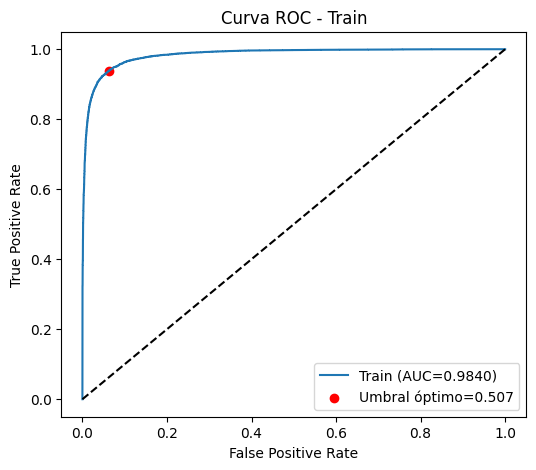


=== Resultados en Test (umbral = 0.50) ===
Accuracy:      0.8505
Sensibilidad:  0.8277
Especificidad: 0.8733
AUC:           0.9289

--- Calibración Youden J ---
Umbral óptimo:        0.4533
Sensibilidad óptima:  0.8643
Especificidad óptima: 0.8434

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8538
Sensibilidad:  0.8643
Especificidad: 0.8434


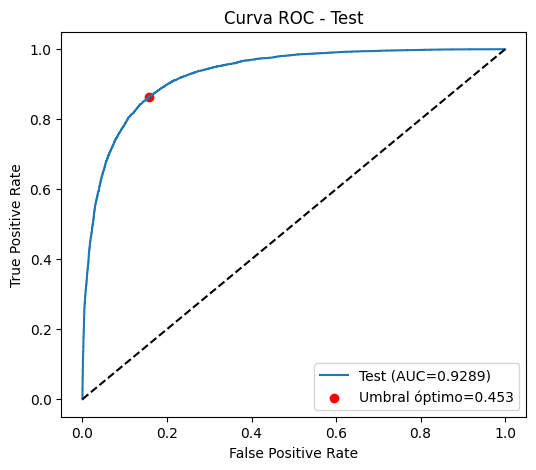

In [201]:
evaluate_model(nb, X_train_tfidf, y_train, "Train")
evaluate_model(nb, X_test_tfidf, y_test, "Test")

## Regresión Logística

In [172]:
# Modelo base (más fácil de que converja)
log_reg = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=2000,   # 5000 no ayuda si el C es muy grande
    tol=1e-3,        # tolerancia menos estricta acelera
)

# Distribución más pequeña (evita C enormes)
param_dist = {
    "C": np.logspace(-2, 2, 12),          # 1e-2 ... 1e2
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9] # discretiza; suficiente
}

# Búsqueda más barata
log_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=12,       # en vez de 30
    cv=3,            # en vez de 5
    scoring="accuracy",
    random_state=1989,
    n_jobs=-1,
    verbose=1
)

In [173]:
log_search.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,LogisticRegre... tol=0.001)
,param_distributions,"{'C': array([1.0000...00000000e+02]), 'l1_ratio': [0.1, 0.3, ...]}"
,n_iter,12
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,1989
,error_score,nan


In [174]:
# Mejores parámetros

best_log = log_search.best_estimator_
print("Mejores parámetros Logistic Regression:", log_search.best_params_)

Mejores parámetros Logistic Regression: {'l1_ratio': 0.1, 'C': 18.73817422860385}


In [175]:
best_c = log_search.best_params_["C"]
best_l1 = log_search.best_params_["l1_ratio"]

In [178]:
# Mejor modelo
best_reglog = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=2000,   # 5000 no ayuda si el C es muy grande
    tol=1e-3,        # tolerancia menos estricta acelera
    C = best_c,
    l1_ratio = best_l1
)

In [179]:
best_reglog.fit(X_train_tfidf, y_train)

,penalty,'elasticnet'
,dual,False
,tol,0.001
,C,18.73817422860385
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [180]:
# Validación cruzada
cv_scores = cross_val_score(best_reglog, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8924
Mediana: 0.8916
Desviación estándar: 0.0037



=== Resultados en Train (umbral = 0.50) ===
Accuracy:      0.9997
Sensibilidad:  0.9997
Especificidad: 0.9998
AUC:           1.0000

--- Calibración Youden J ---
Umbral óptimo:        0.4908
Sensibilidad óptima:  0.9998
Especificidad óptima: 0.9998

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9998
Sensibilidad:  0.9998
Especificidad: 0.9998


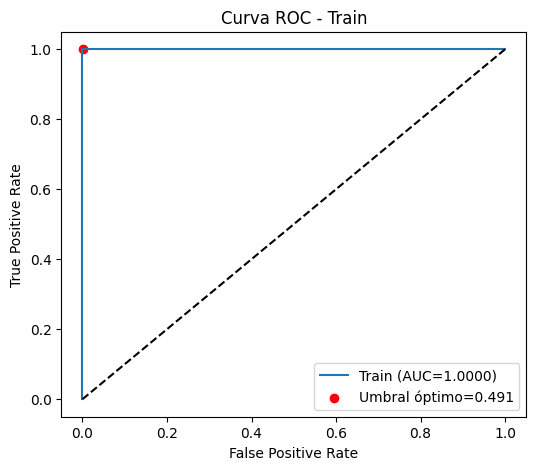


=== Resultados en Test (umbral = 0.50) ===
Accuracy:      0.8785
Sensibilidad:  0.8723
Especificidad: 0.8847
AUC:           0.9507

--- Calibración Youden J ---
Umbral óptimo:        0.4454
Sensibilidad óptima:  0.8919
Especificidad óptima: 0.8674

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8797
Sensibilidad:  0.8919
Especificidad: 0.8674


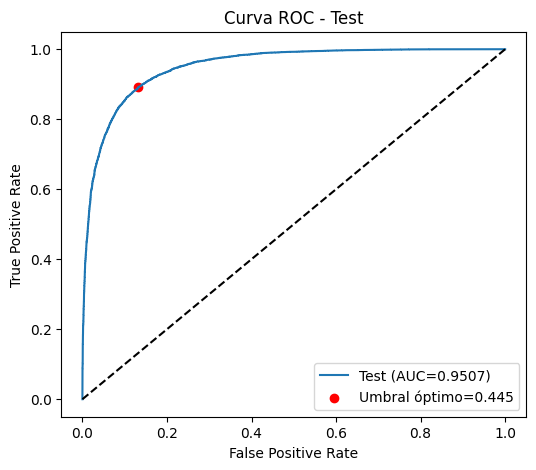

In [202]:
# Evaluación del rendimiento
evaluate_model(best_reglog, X_train_tfidf, y_train, "Train")
evaluate_model(best_reglog, X_test_tfidf, y_test, "Test")

## Linear SVC

In [190]:
def train_linear_svc(Xtr, ytr, cv=3):
    base = LinearSVC(
        max_iter=10000,   # ↑ iteraciones
        tol=1e-3,         # tolerancia menos estricta
        dual=True,        # mejor cuando n_features >> n_samples
        loss="squared_hinge"
    )
    grid = {"C": np.logspace(-3, 2, 11)}  # 1e-3 ... 1e2 (sin 1e3)
    gs = GridSearchCV(base, grid, cv=cv, n_jobs=-1, scoring="accuracy", verbose=1)
    gs.fit(Xtr, ytr)
    return gs.best_estimator_, gs.best_params_

In [191]:
svm_best, svm_params = train_linear_svc(X_train_tfidf, y_train, cv=3)

Fitting 3 folds for each of 11 candidates, totalling 33 fits


In [194]:
# Validación cruzada
cv_scores = cross_val_score(svm_best, X_train_tfidf, y_train, cv=5, scoring="accuracy")
print("\n=== Cross Validation ===")
print(f"Media: {cv_scores.mean():.4f}")
print(f"Mediana: {np.median(cv_scores):.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")


=== Cross Validation ===
Media: 0.8940
Mediana: 0.8938
Desviación estándar: 0.0038



=== Resultados en Train (umbral = 0.00) ===
Accuracy:      0.9811
Sensibilidad:  0.9836
Especificidad: 0.9786
AUC:           0.9980

--- Calibración Youden J ---
Umbral óptimo:        0.0349
Sensibilidad óptima:  0.9800
Especificidad óptima: 0.9834

=== Resultados en Train (umbral óptimo) ===
Accuracy:      0.9817
Sensibilidad:  0.9800
Especificidad: 0.9834


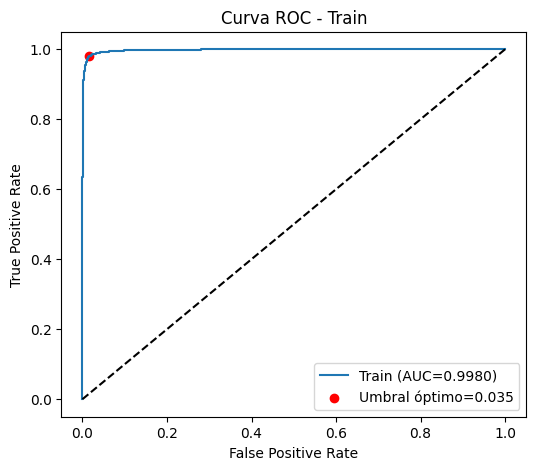


=== Resultados en Test (umbral = 0.00) ===
Accuracy:      0.8840
Sensibilidad:  0.8826
Especificidad: 0.8854
AUC:           0.9532

--- Calibración Youden J ---
Umbral óptimo:        -0.0071
Sensibilidad óptima:  0.8858
Especificidad óptima: 0.8833

=== Resultados en Test (umbral óptimo) ===
Accuracy:      0.8845
Sensibilidad:  0.8858
Especificidad: 0.8833


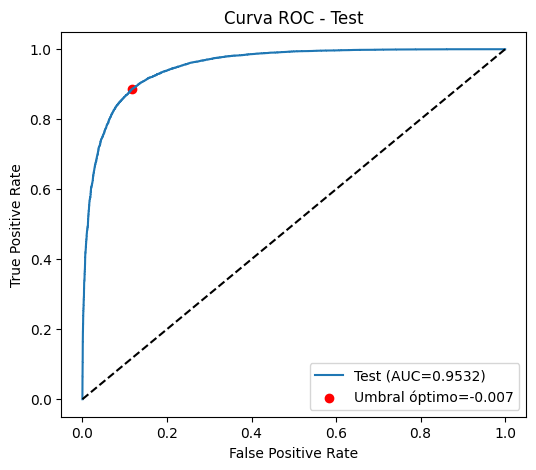

In [203]:
# Para LinearSVC (usa decision_function)
evaluate_model(svm_best, X_train_tfidf, y_train, "Train")
evaluate_model(svm_best, X_test_tfidf,  y_test,  "Test")

In [206]:
def results_model(model, X, y, model_name: str, dataset_name="Dataset"):
    # 1) Obtener "scores" y umbral por defecto según el tipo de modelo
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)[:, 1]
        default_thr = 0.5
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        default_thr = 0.0          # frontera de decisión en SVM lineal
    else:
        # fallback mínimo: solo métricas con predicción discreta
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)
        acc = accuracy_score(y, y_pred)
        sens = recall_score(y, y_pred)
        spec = cm[0,0] / (cm[0,0] + cm[0,1])
        print(f"\n=== Resultados en {dataset_name} (sin scores) ===")
        print(f"Accuracy: {acc:.4f}  Sens: {sens:.4f}  Esp: {spec:.4f}")
        print("AUC/ROC no disponible (el modelo no da scores).")
        return

    # 2) Métricas con umbral por defecto
    y_pred_default = (scores >= default_thr).astype(int)
    cm = confusion_matrix(y, y_pred_default)
    acc = accuracy_score(y, y_pred_default)
    sens = recall_score(y, y_pred_default)
    spec = cm[0,0] / (cm[0,0] + cm[0,1])
    auc = roc_auc_score(y, scores)

    """print(f"\n=== Resultados en {dataset_name} (umbral = {default_thr:.2f}) ===")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Sensibilidad:  {sens:.4f}")
    print(f"Especificidad: {spec:.4f}")
    print(f"AUC:           {auc:.4f}")"""

    # 3) Umbral óptimo (Youden J) + curva ROC
    fpr, tpr, thresholds = roc_curve(y, scores)
    specificity = 1 - fpr
    J = tpr + specificity - 1
    idx_opt = np.argmax(J)
    best_threshold = thresholds[idx_opt]

    """print(f"\n--- Calibración Youden J ---")
    print(f"Umbral óptimo:        {best_threshold:.4f}")
    print(f"Sensibilidad óptima:  {tpr[idx_opt]:.4f}")
    print(f"Especificidad óptima: {specificity[idx_opt]:.4f}")"""

    # 4) Métricas con umbral óptimo
    y_pred_opt = (scores >= best_threshold).astype(int)
    cm_opt = confusion_matrix(y, y_pred_opt)
    acc_opt = accuracy_score(y, y_pred_opt)
    sens_opt = recall_score(y, y_pred_opt)
    spec_opt = cm_opt[0,0] / (cm_opt[0,0] + cm_opt[0,1])

    """print(f"\n=== Resultados en {dataset_name} (umbral óptimo) ===")
    print(f"Accuracy:      {acc_opt:.4f}")
    print(f"Sensibilidad:  {sens_opt:.4f}")
    print(f"Especificidad: {spec_opt:.4f}")"""

    """# 5) Curva ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{dataset_name} (AUC={auc:.4f})")
    plt.plot([0,1], [0,1], "k--")
    plt.scatter(fpr[idx_opt], tpr[idx_opt], color='red', label=f"Umbral óptimo={best_threshold:.3f}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {dataset_name}")
    plt.legend(); plt.show()"""

    return {
        "Model": model_name,
        "Split": dataset_name, 
        "Accuracy": acc_opt, 
        "Sensibilidad": sens_opt, 
        "Especificidad": spec_opt,
        "AUC": auc,
        "Best Umbral": best_threshold
    }

In [207]:
resultados = [
    results_model(nb, X_train_tfidf, y_train, "Bayessiano", "Train"),
    results_model(nb, X_test_tfidf,  y_test,  "Bayessiano", "Test"),
    results_model(best_reglog, X_train_tfidf, y_train, "Reg Log", "Train"),
    results_model(best_reglog, X_test_tfidf,  y_test,  "Reg Log", "Test"),
    results_model(svm_best, X_train_tfidf, y_train, "SVM", "Train"),
    results_model(svm_best, X_test_tfidf,  y_test,  "SVM", "Test")
]

In [208]:
pd.DataFrame(resultados)

,Model,Split,Accuracy,Sensibilidad,Especificidad,AUC,Best Umbral
0,Bayessiano,Train,0.93812,0.93856,0.93768,0.983976,0.506978
1,Bayessiano,Test,0.85384,0.86432,0.84336,0.928901,0.453252
2,Reg Log,Train,0.99976,0.99976,0.99976,1.000000,0.490783
3,Reg Log,Test,0.87968,0.89192,0.86744,0.950685,0.445355
4,SVM,Train,0.98172,0.98000,0.98344,0.997994,0.034879
5,SVM,Test,0.88452,0.88576,0.88328,0.953218,-0.007053


* El SVM lineal obtuvo mayor AUC y accuracy en test
* La Regresión Logística maximizó la sensibilidad
* Seleccionamos SVM como mejor modelo por desempeño global (AUC/accuracy) y guardamos el pipeline + umbral óptimo para despliegue.

## Guardar Mejor Modelo (Pipeline completo)

In [209]:
svm_final = make_pipeline(tfidf, svm_best)  # usa el tfidf ajustado a TRAIN y el mejor SVM

scores_tr = svm_final.decision_function(df.loc[df.split=="train","text_clean"])
y_tr = df.loc[df.split=="train","label"].values
fpr, tpr, thr = roc_curve(y_tr, scores_tr)
youden = tpr - (1 - fpr)
thr_opt = float(thr[np.argmax(youden)])

bundle = {"pipeline": svm_final, "threshold": thr_opt}

with open("best_svm_imdb.pkl", "wb") as f:
    pickle.dump(bundle, f)

## Carga del mejor modelo (posterior)

In [ ]:
with open("best_svm_imdb.pkl", "rb") as f:
    bundle = pickle.load(f)

pipe = bundle["pipeline"]
thr  = bundle["threshold"]

def predict_labels(texts):
    scores = pipe.decision_function(texts)   # LinearSVC
    return (scores >= thr).astype(int)

# y_pred = predict_labels(["great movie!", "awful plot..."])

# Demanda de ecobicis — Predicción con SVR

* **Datos**: utiliza el dataset **Seoul Bike Sharing Demand** (bicicletas rentadas en Seúl) de UCI ML Repository: [https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand).
* Construye un **modelo de regresión** con **cada uno de los kernels de SVR**, usando como **variable objetivo** `Rented Bike Count`.
* Tras el **análisis de datos**, **encuentra tu mejor modelo** y **compara y concluye**.

In [1]:
# !pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
seoul_bike_sharing_demand = fetch_ucirepo(id=560) 
  
# data (as pandas dataframes) 
X = seoul_bike_sharing_demand.data.features 
y = seoul_bike_sharing_demand.data.targets 
  
# metadata 
print('Metadata\n')
print(seoul_bike_sharing_demand.metadata.keys(), end='\n\n')
print(seoul_bike_sharing_demand.metadata['name'], end='\n\n')
print(seoul_bike_sharing_demand.metadata['abstract'], end='\n\n')
  
# variable information 
display(seoul_bike_sharing_demand.variables) 

Metadata

dict_keys(['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info'])

Seoul Bike Sharing Demand

The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information



,name,role,type,demographic,description,units,missing_values
0,Date,Feature,Date,None,None,None,no
1,Rented Bike Count,Feature,Integer,None,None,None,no
2,Hour,Feature,Integer,None,None,None,no
3,Temperature,Feature,Continuous,None,None,C,no
4,Humidity,Feature,Integer,None,None,%,no
5,Wind speed,Feature,Continuous,None,None,m/s,no
6,Visibility,Feature,Integer,None,None,10m,no
7,Dew point temperature,Feature,Continuous,None,None,C,no
8,Solar Radiation,Feature,Continuous,None,None,Mj/m2,no
9,Rainfall,Feature,Integer,None,None,mm,no


In [3]:
bici = pd.concat([X, y], axis=1)

In [4]:
bici.shape

(8760, 14)

In [5]:
bici.head(3)

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
def is_na_df(df):
    #Establecemos el resumen de NAs por columna
    na_summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "columna", 0: "n_missing"})
    )

    #Tomamos totales y prporciones
    na_summary["total"] = len(df)
    na_summary["prop_missing"] = na_summary["n_missing"] / na_summary["total"]
    na_summary["prop_original"] = 1 - na_summary["prop_missing"]

    #Filtramos solo columnas con al menos 1 NA
    na_summary = na_summary[na_summary["n_missing"] > 0].reset_index(drop=True)

    #Agregamos fila resumen global
    total_missing = df.isna().sum().sum()
    total_elements = df.size
    prop_missing_global = total_missing / total_elements
    prop_original_global = 1 - prop_missing_global

    resumen = pd.DataFrame({
        "columna": ["TOTAL"],
        "n_missing": [total_missing],
        "total": [total_elements],
        "prop_missing": [prop_missing_global],
        "prop_original": [prop_original_global]
    })

    na_summary = pd.concat([na_summary, resumen], ignore_index=True)

    return na_summary

In [7]:
is_na_df(bici)

,columna,n_missing,total,prop_missing,prop_original
0,TOTAL,0,122640,0.0,1.0


No hay valores nulos.

In [8]:
bici_clean = bici.copy()

In [9]:
bici_clean.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [10]:
bici_clean['Month'] = pd.to_datetime(bici_clean['Date'], format='%d/%m/%Y').apply(lambda x: x.strftime('%m')).astype(int)

In [11]:
bici_clean['Month'].value_counts(normalize=True).sort_index().apply(lambda x: '{0:.2%}'.format(x))

Month
1     8.49%
2     7.67%
3     8.49%
4     8.22%
5     8.49%
6     8.22%
7     8.49%
8     8.49%
9     8.22%
10    8.49%
11    8.22%
12    8.49%
Name: proportion, dtype: object

In [12]:
bici_clean['Year'] = pd.to_datetime(bici_clean['Date'], format='%d/%m/%Y').apply(lambda x: x.strftime('%Y')).astype(int)

In [13]:
bici_clean['Year'].value_counts(normalize=True).sort_index().apply(lambda x: '{0:.2%}'.format(x))

Year
2017     8.49%
2018    91.51%
Name: proportion, dtype: object

In [14]:
bici_clean.drop(columns=['Year'], inplace=True)

In [15]:
bici_clean['Day_Name'] = pd.to_datetime(bici_clean['Date'], format='%d/%m/%Y').apply(lambda x: x.strftime('%A'))

In [16]:
bici_clean['Day_Name'].value_counts(normalize=True).sort_index().apply(lambda x: '{0:.2%}'.format(x))

Day_Name
Friday       14.52%
Monday       14.25%
Saturday     14.25%
Sunday       14.25%
Thursday     14.25%
Tuesday      14.25%
Wednesday    14.25%
Name: proportion, dtype: object

In [17]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2)

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#de3163"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#31deac", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values,textinfo='label+value+percent',
                    marker=dict(colors=["#de3163", "#31deac"])
                                )
                    ]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Inferno'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [18]:
bici_clean.drop(columns=['Date'], inplace=True)

In [19]:
var_cat = bici_clean.select_dtypes('object').columns.to_list()
var_num = [x for x in bici_clean.columns if x not in var_cat] 

In [20]:
bici_analisis = analyze(bici_clean, num_vars=var_num, cat_vars=var_cat)

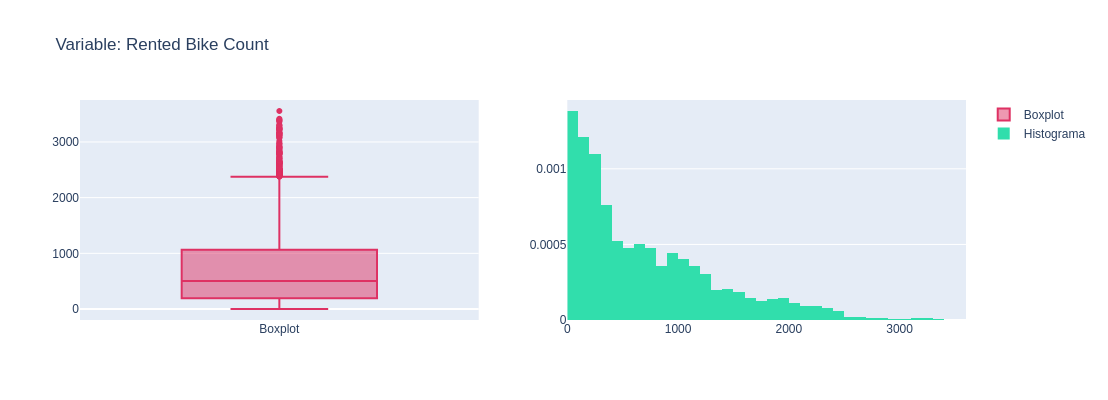

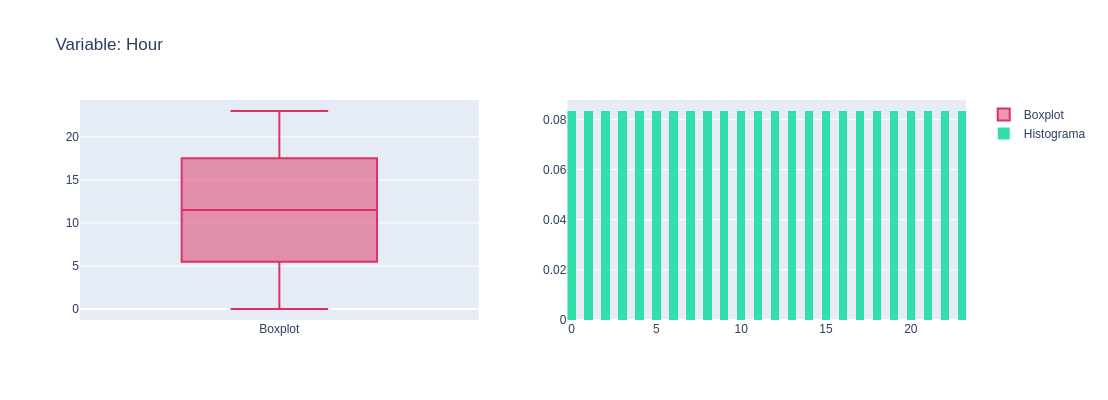

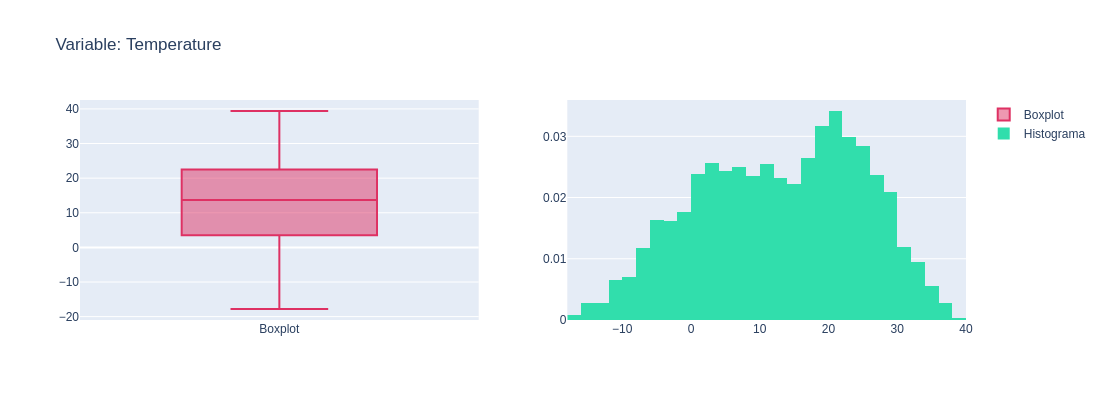

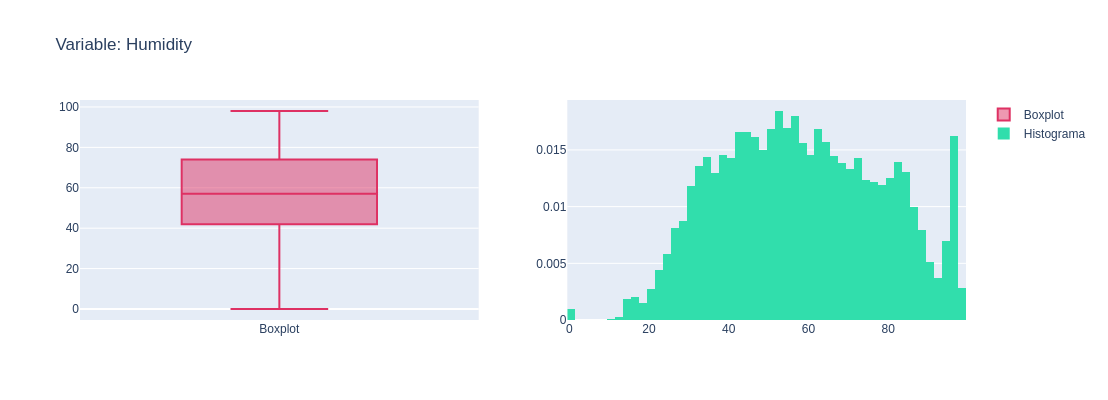

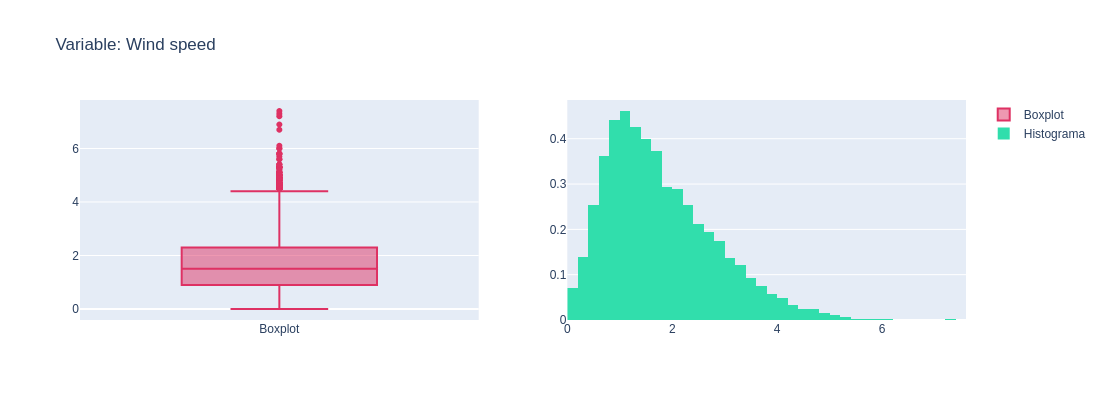

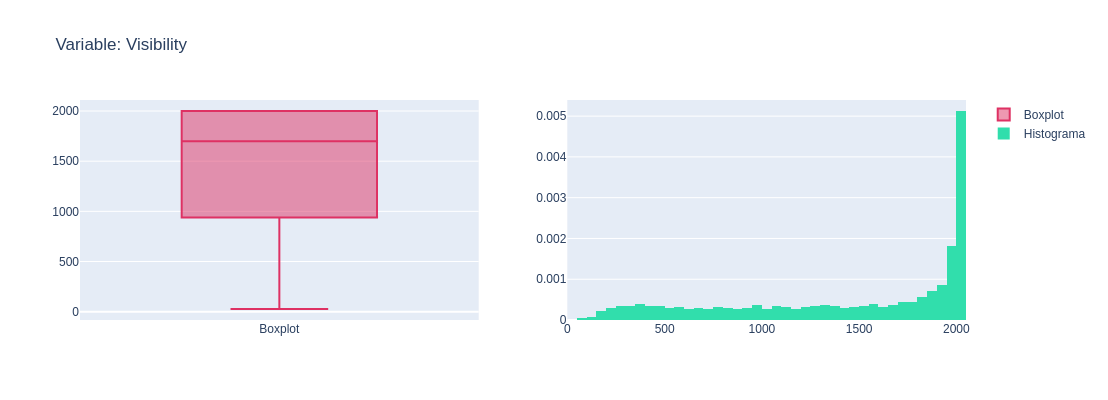

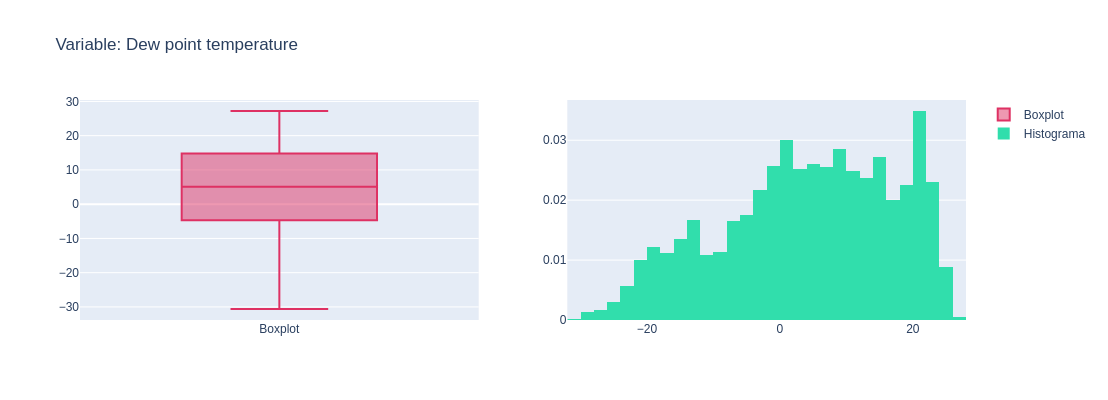

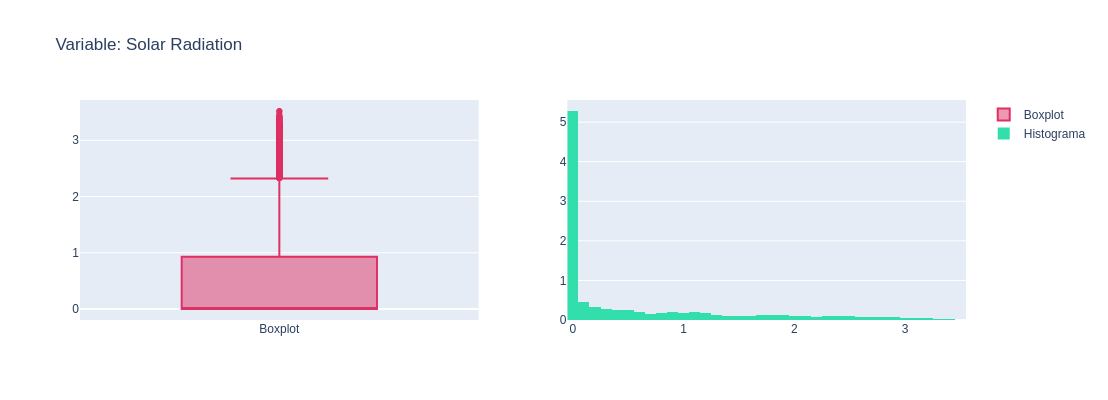

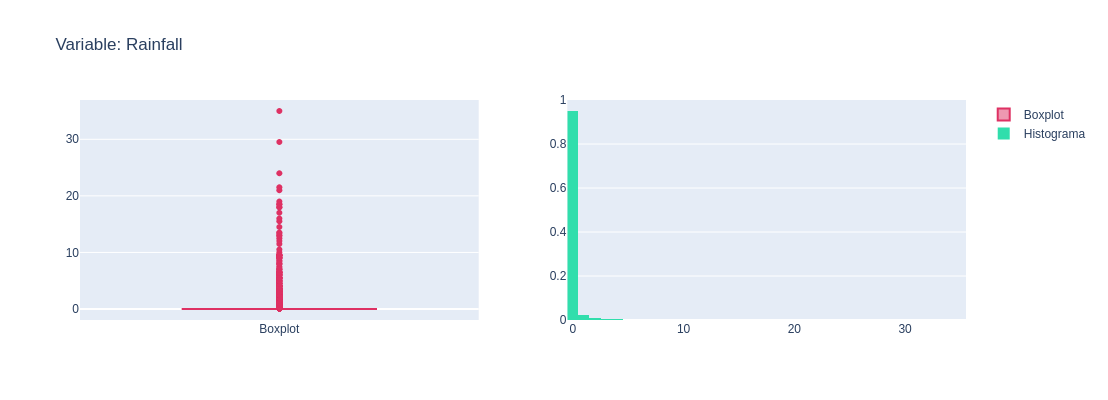

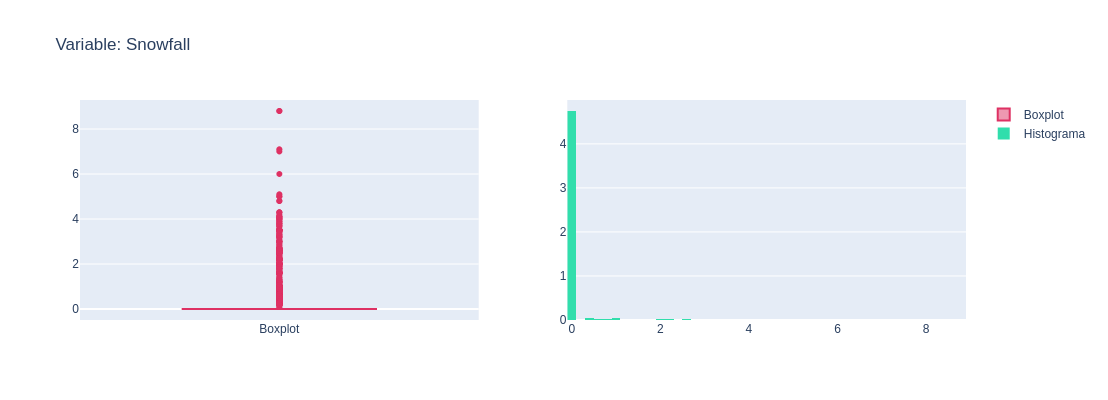

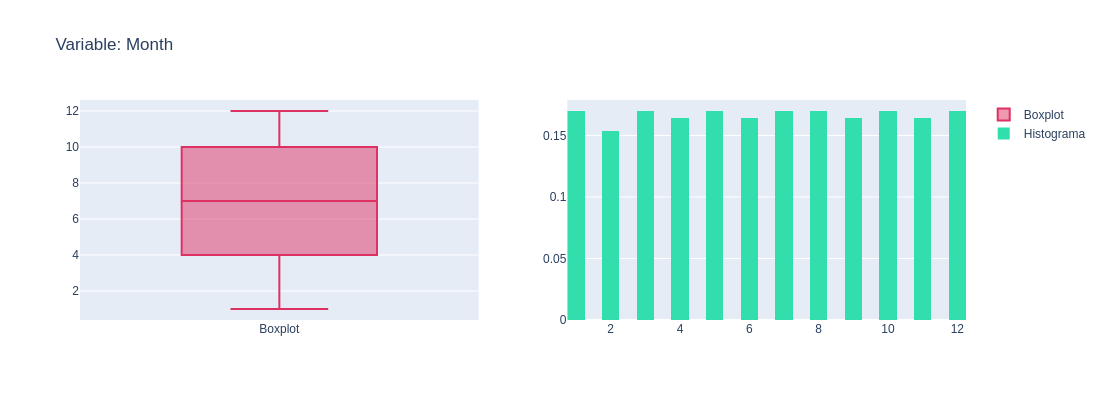

In [21]:
bici_analisis.plot_num()

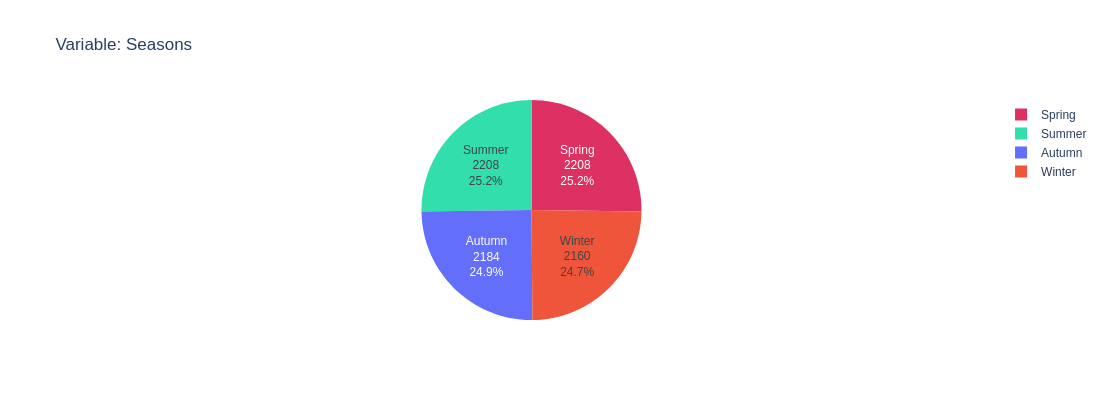

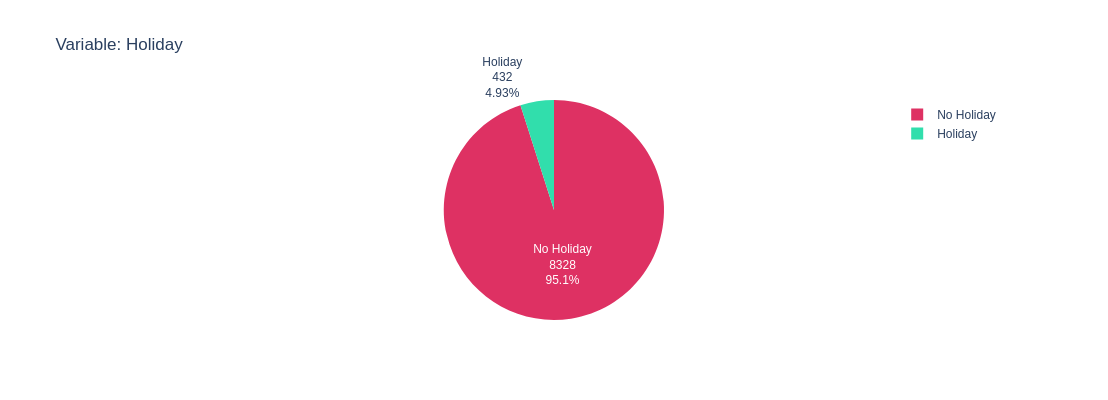

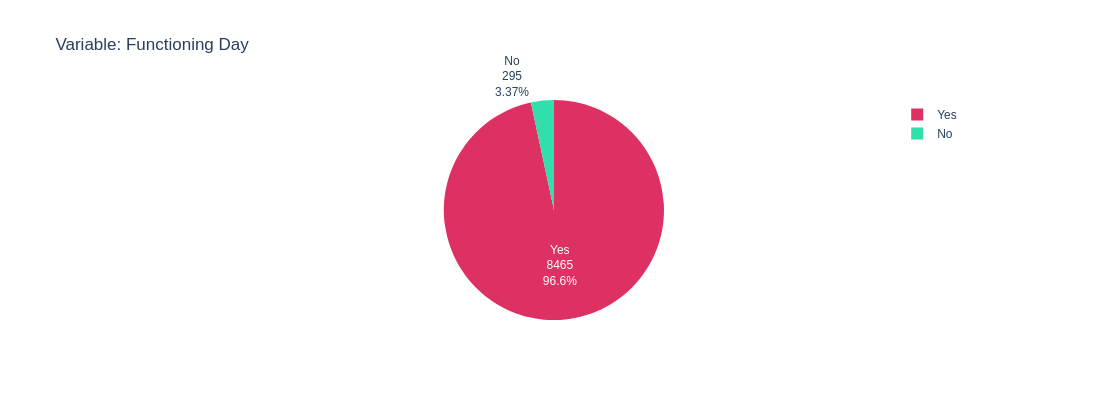

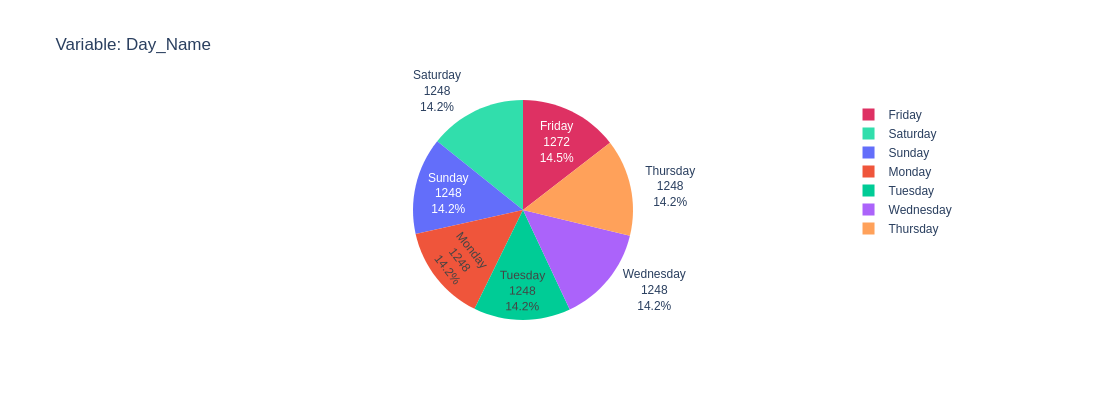

In [22]:
bici_analisis.plot_cat()

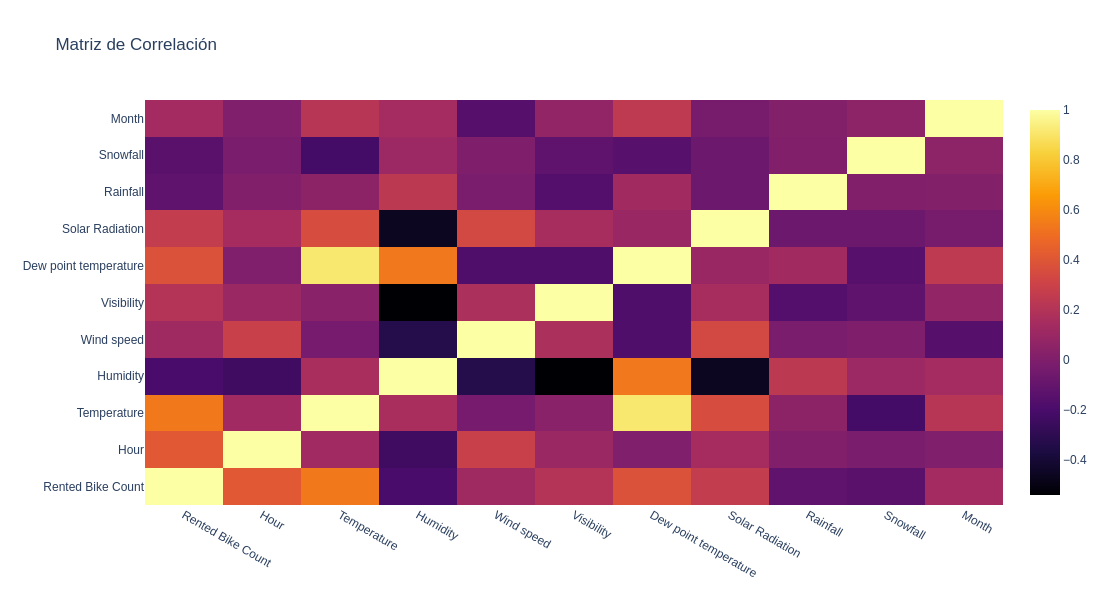

In [23]:
bici_analisis.corr_matrix()

In [24]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

### Días con lluvia

In [25]:
bici_clean['Rainy Day'] = bici_clean['Rainfall'].apply(lambda x: 1 if x != 0 else 0)

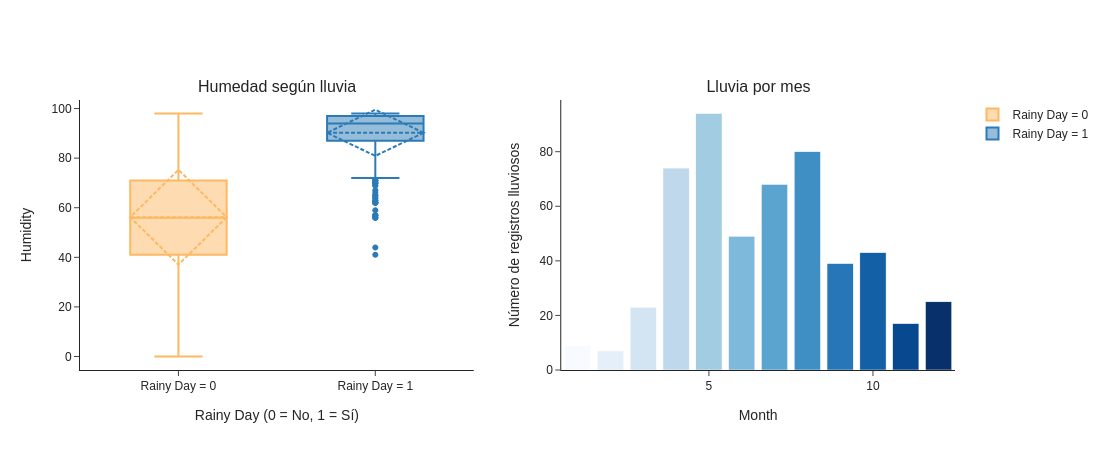

In [26]:
# Aseguramos tipo de la variable binaria
bici_clean["Rainy Day"] = bici_clean["Rainy Day"].astype(int)

# Colores para lluvia / no lluvia
rainy_colors = {0: "#FDB863",   # no lluvia
                1: "#2C7BB6"}   # lluvia

# --- Agregamos lluvia por mes (conteo de registros lluviosos) ---
rainy_by_month = (
    bici_clean
    .groupby("Month")["Rainy Day"]
    .sum()
    .reset_index()
)

# --- Figura con subplots (1 fila, 2 columnas) ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Humedad según lluvia", "Lluvia por mes")
)

# --------- 1) BOX: Humidity vs Rainy Day ----------
for val in [0, 1]:
    subset = bici_clean[bici_clean["Rainy Day"] == val]
    fig.add_trace(
        go.Box(
            y=subset["Humidity"],
            name=f"Rainy Day = {val}",
            marker_color=rainy_colors[val],
            boxmean="sd",      # muestra media y desviación
            showlegend=True
        ),
        row=1, col=1
    )

# --------- 2) BARRAS: Lluvia por mes ----------
fig.add_trace(
    go.Bar(
        x=rainy_by_month["Month"],
        y=rainy_by_month["Rainy Day"],
        marker=dict(
            color=rainy_by_month["Month"],
            colorscale="Blues"
        ),
        showlegend=False
    ),
    row=1, col=2
)

# --- Etiquetas y estilo general ---
fig.update_xaxes(title_text="Rainy Day (0 = No, 1 = Sí)", row=1, col=1)
fig.update_yaxes(title_text="Humidity", row=1, col=1)

fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_yaxes(title_text="Número de registros lluviosos", row=1, col=2)

fig.update_layout(
    template="simple_white",
    width=1100,
    height=450
)

fig.show()

### Días con Nieve

In [27]:
bici_clean['Snowy Day'] = bici_clean['Snowfall'].apply(lambda x: 1 if x != 0 else 0)

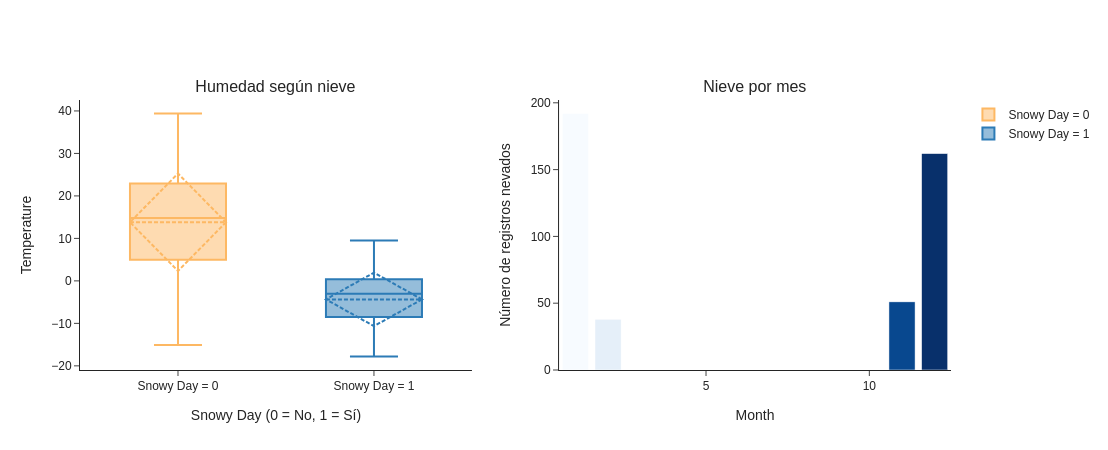

In [28]:
# Aseguramos tipo de la variable binaria
bici_clean["Snowy Day"] = bici_clean["Snowy Day"].astype(int)

# Colores para lluvia / no lluvia
rainy_colors = {0: "#FDB863",   # no lluvia
                1: "#2C7BB6"}   # lluvia

# --- Agregamos lluvia por mes (conteo de registros lluviosos) ---
rainy_by_month = (
    bici_clean
    .groupby("Month")["Snowy Day"]
    .sum()
    .reset_index()
)

# --- Figura con subplots (1 fila, 2 columnas) ---
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Humedad según nieve", "Nieve por mes")
)

# --------- 1) BOX: Humidity vs Rainy Day ----------
for val in [0, 1]:
    subset = bici_clean[bici_clean["Snowy Day"] == val]
    fig.add_trace(
        go.Box(
            y=subset["Temperature"],
            name=f"Snowy Day = {val}",
            marker_color=rainy_colors[val],
            boxmean="sd",      # muestra media y desviación
            showlegend=True
        ),
        row=1, col=1
    )

# --------- 2) BARRAS: Lluvia por mes ----------
fig.add_trace(
    go.Bar(
        x=rainy_by_month["Month"],
        y=rainy_by_month["Snowy Day"],
        marker=dict(
            color=rainy_by_month["Month"],
            colorscale="Blues"
        ),
        showlegend=False
    ),
    row=1, col=2
)

# --- Etiquetas y estilo general ---
fig.update_xaxes(title_text="Snowy Day (0 = No, 1 = Sí)", row=1, col=1)
fig.update_yaxes(title_text="Temperature", row=1, col=1)

fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_yaxes(title_text="Número de registros nevados", row=1, col=2)

fig.update_layout(
    template="simple_white",
    width=1100,
    height=450
)

fig.show()

In [29]:
N = bici_clean.shape[0]

In [30]:
n1 = bici_clean.loc[bici_clean['Rainy Day'] == 1].shape[0]

In [31]:
print('{0} Días lluviosos ({1:.2%})'.format(n1, n1/N))

528 Días lluviosos (6.03%)


In [32]:
n2 = bici_clean.loc[bici_clean['Snowy Day'] == 1].shape[0]

In [33]:
print('{0} Días lluviosos ({1:.2%})'.format(n2, n2/N))

443 Días lluviosos (5.06%)


In [34]:
bici_clean.drop(columns=['Rainy Day', 'Snowy Day', 'Snowfall', 'Rainfall', 'Functioning Day', 'Holiday'], inplace=True)

### Renta de Bicis por estación del año y por mes

In [35]:
fmt_num = lambda x: '{0:,.0f}'.format(x)

In [36]:
bici_clean.groupby('Seasons')['Rented Bike Count'].sum().apply(fmt_num)

Seasons
Autumn    1,790,002
Spring    1,611,909
Summer    2,283,234
Winter      487,169
Name: Rented Bike Count, dtype: object

In [37]:
bici_clean.groupby('Month')['Rented Bike Count'].sum().apply(fmt_num)

Month
1     150,006
2     151,833
3     380,594
4     524,227
5     707,088
6     896,887
7     734,460
8     651,887
9     673,612
10    650,675
11    465,715
12    185,330
Name: Rented Bike Count, dtype: object

## Codificación de Variables

In [38]:
var_cat = bici_clean.select_dtypes('object').columns.to_list() + ['Hour']
var_num = [x for x in bici_clean.columns if x not in var_cat]

In [39]:
print('Variables categóricas -', ', '.join(var_cat))
print('Variables numéricas -', ', '.join(var_num))

Variables categóricas - Seasons, Day_Name, Hour
Variables numéricas - Rented Bike Count, Temperature, Humidity, Wind speed, Visibility, Dew point temperature, Solar Radiation, Month


In [40]:
y = 'Rented Bike Count'

In [41]:
y_col = 'Rented Bike Count'

# Variables explicativas (todas menos la y)
X = bici_clean.drop(columns=[y_col])
y = bici_clean[y_col]

In [42]:
# OneHotEncoder
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_cat_encoded = ohe.fit_transform(X[var_cat])

cat_cols = ohe.get_feature_names_out(var_cat)
X_cat_df = pd.DataFrame(X_cat_encoded, columns=cat_cols, index=X.index)

# Separar numéricas
var_num_clean = [x for x in var_num if x != 'Rented Bike Count']

# Concatenar numéricas (sin escalar) + categóricas
X_num_df = X[var_num_clean].copy()

X_processed = pd.concat([X_num_df, X_cat_df], axis=1)

# Ahora sí: HACER EL SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.3,
    random_state=7725
)

In [45]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6132, 39), (2628, 39), (6132,), (2628,))

In [43]:
scaler = MinMaxScaler()

# Ajustar SOLO con train
X_train_scaled = scaler.fit_transform(X_train)

# Transformar test con los parámetros del train
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [44]:
X_train_scaled

,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Month,Seasons_Spring,Seasons_Summer,Seasons_Winter,...,Hour_14,Hour_15,Hour_16,Hour_17,Hour_18,Hour_19,Hour_20,Hour_21,Hour_22,Hour_23
5838,0.797203,0.744898,0.123288,0.985302,0.918685,0.002841,0.636364,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4510,0.674825,0.795918,0.246575,0.373036,0.820069,0.000000,0.454545,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1666,0.201049,0.469388,0.178082,0.668525,0.252595,0.286932,0.090909,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5523,0.737762,0.867347,0.082192,0.329954,0.904844,0.000000,0.545455,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4202,0.592657,0.714286,0.082192,0.385200,0.712803,0.000000,0.363636,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7283,0.664336,0.642857,0.383562,0.591992,0.752595,0.355114,0.727273,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7511,0.601399,0.540816,0.150685,1.000000,0.648789,0.000000,0.818182,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5902,0.846154,0.653061,0.164384,0.850482,0.927336,0.000000,0.636364,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8311,0.370629,0.734694,0.136986,0.994425,0.510381,0.000000,0.909091,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# Función de métricas
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    
    # Evitar división por cero en MAPE
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mask = y_true != 0        # solo donde el real NO es cero
    if mask.sum() == 0:
        mape = np.nan         # no hay valores válidos para MAPE
    else:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    return rmse, mae, mape

# ====================================================
# 1. Espacio de búsqueda de hiperparámetros
#    (con los 4 kernels pero más acotado)
# ====================================================

param_dist = [
    # ---- kernel lineal: solo C y epsilon importan ----
    {
        'kernel': ['linear'],
        'C': np.logspace(-1, 3, 6),          # 0.1 ... 1000
        'epsilon': [0.01, 0.05, 0.1, 0.2]
    },

    # ---- kernel RBF ----
    {
        'kernel': ['rbf'],
        'C': np.logspace(0, 3, 6),           # 1 ... 1000
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'epsilon': [0.01, 0.05, 0.1, 0.2]
    },

    # ---- kernel polinomial ----
    {
        'kernel': ['poly'],
        'C': np.logspace(0, 3, 6),           # 1 ... 1000
        'gamma': ['scale', 'auto', 0.01],
        'degree': [2, 3],                    # grados moderados
        'coef0': [0.0, 1.0],
        'epsilon': [0.01, 0.1]
    },

    # ---- kernel sigmoidal ----
    {
        'kernel': ['sigmoid'],
        'C': np.logspace(-1, 3, 6),          # 0.1 ... 1000
        'gamma': ['scale', 'auto', 0.01],
        'coef0': [0.0, 1.0],
        'epsilon': [0.01, 0.1]
    }
]

# Modelo base
svr = SVR()

# ====================================================
# 2. RandomizedSearchCV (más ligero pero completo)
# ====================================================

random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist,
    n_iter=40,                             # sigues cumpliendo con 40 iteraciones
    scoring='neg_root_mean_squared_error',
    cv=3,                                  # 3 folds (antes 5) → menos tiempo
    random_state=1989,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

best_svr = random_search.best_estimator_

print("\nMejores parámetros encontrados:")
print(random_search.best_params_)

# ====================================================
# 3. Predicciones y métricas
# ====================================================

y_pred_train = best_svr.predict(X_train_scaled)
y_pred_test  = best_svr.predict(X_test_scaled)

rmse_train, mae_train, mape_train = regression_metrics(y_train, y_pred_train)
rmse_test,  mae_test,  mape_test  = regression_metrics(y_test,  y_pred_test)

results = pd.DataFrame({
    'Set':      ['Entrenamiento', 'Prueba'],
    'RMSE':     [rmse_train, rmse_test],
    'MAE':      [mae_train, mae_test],
    'MAPE (%)': [mape_train, mape_test]
})

display(results)
print("\n✅ Entrenamiento y evaluación completados.")

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Mejores parámetros encontrados:
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.05, 'C': 1000.0}


,Set,RMSE,MAE,MAPE (%)
0,Entrenamiento,289.864253,142.254167,67.730066
1,Prueba,313.698804,175.754432,89.062435



✅ Entrenamiento y evaluación completados.


> “Debido a que la variable objetivo (rentas de bicis) puede tomar valores de 0, el cálculo de MAPE estándar produce valores infinitos por división entre cero. Por ello, el MAPE se calculó excluyendo los casos con valor real igual a 0, manteniendo RMSE y MAE como métricas principales de desempeño.”

## Idea para conclusiones

# ✅ **Interpretación de resultados del modelo SVR (Regresión con SVM)**

### **1. Desempeño del modelo**

Los mejores hiperparámetros encontrados fueron:

```python
{'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.05, 'C': 1000.0}
```

Este resultado es totalmente consistente: el kernel **RBF** suele funcionar muy bien cuando las relaciones entre variables son no lineales (que es el caso de clima + demanda).

### **2. Interpretación de métricas**

| Set           | RMSE | MAE  | MAPE (%) |
| ------------- | ---- | ---- | -------- |
| Entrenamiento | ~289 | ~142 | ~68%     |
| Prueba        | ~313 | ~176 | ~89%     |

Te dejo una explicación lista para implementar:

---

### 🔹 **RMSE (Root Mean Squared Error)**

* Un **RMSE ≈ 313** en prueba significa que, en promedio, el modelo se equivoca por **±313 bicicletas** cuando predice la demanda.
* Considerando que los valores de renta pueden superar fácilmente **800–900 bicicletas por hora**, el RMSE está **dentro de un rango razonable**.
* El hecho de que el RMSE de prueba solo sea ligeramente mayor al de entrenamiento indica que **no hay sobreajuste severo**.

> **Interpretación sencilla:**
> El modelo logra capturar buena parte de la variabilidad de la demanda, aunque aún presenta errores moderados cuando las condiciones cambian (clima, hora, temporada).

---

### 🔹 **MAE (Mean Absolute Error)**

* El MAE ≈ 176 significa que, en términos absolutos, el modelo en promedio se equivoca por **176 bicicletas**.
* Es un valor coherente con el dinamismo del sistema (rentas horarias pueden variar entre 0 y más de 1,000).

> **Interpretación:**
> El modelo tiende a subestimar o sobreestimar la demanda por aproximadamente 176 bicicletas por hora.

---

### 🔹 **MAPE**

Aunque ya lo corregimos para no dividir entre cero, sigue siendo:

* Entrenamiento: ~68%
* Prueba: ~89%

Esto **no significa que el modelo sea malo**, sino que **MAPE no es adecuado** cuando:

* hay muchos valores pequeños o iguales a 0 (como horas con poca demanda),
* o variaciones muy bruscas.

Exactamente tu caso.

> **Interpretación recomendada:**
> El MAPE es alto porque la demanda horaria de bicicletas puede tomar valores muy pequeños e incluso cero, lo cual hace que esta métrica no sea representativa. Por ello, RMSE y MAE son indicadores mucho más confiables en este problema.

---

# 🟦 **Conclusión técnica resumida**

> El modelo SVR con kernel RBF obtiene un desempeño adecuado para un entorno con alta variabilidad como el uso de bicicletas compartidas. El RMSE y MAE muestran errores moderados y consistentes entre entrenamiento y prueba, lo que indica un modelo relativamente estable y sin sobreajuste importante. Aunque el MAPE se ve elevado, esto se debe a la naturaleza misma de la variable objetivo. En general, el modelo es funcional para estimar tendencias de demanda más que valores exactos por hora.

---

# 📊 **Interpretación ejecutiva de los gráficos**

Ahora te dejo textos que puedes pegar directamente en tus slides:

---

## 🟧 **1. Humedad según lluvia**

> Las horas con lluvia presentan niveles significativamente más altos de humedad, con menor variabilidad. Esto confirma la relación directa entre el clima húmedo y la ocurrencia de lluvia. **(Incluir gráfico 1 de Lluvia)**

## 🟦 **2. Lluvia por mes**

> Los meses de primavera y verano concentran el mayor número de días lluviosos, mientras que el invierno muestra menor presencia de lluvia. Esto sugiere patrones estacionales claros de humedad y precipitación. **(Incluir gráfico 2 de Lluvia)**

---

## ❄️ **3. Temperatura según nieve**

> Cuando hay nieve, las temperaturas caen de manera notable, con valores cercanos o inferiores a cero. Esto confirma la fuerte asociación entre condiciones de nieve y temperaturas bajas. **(Incluir gráfico 1 de Nieve)**

---

## ❄️📆 **4. Nieve por mes**

> La nieve aparece principalmente en los meses invernales (enero, diciembre), con muy poca presencia en el resto del año. Este patrón estacional es útil para anticipar demanda reducida en temporada fría. **(Incluir gráfico 2 de Nieve)**

---

# 🏁 **Resumen ejecutivo (para slide final)**

> El análisis confirma que tanto la lluvia como la nieve tienen comportamientos estacionales marcados y afectan directamente condiciones como la humedad y la temperatura. Estos patrones climáticos explican buena parte de la variabilidad en la demanda de bicicletas y deben considerarse en estrategias operativas y de planeación. (Mostrar resultados)

---

## Idea para presentación

# 🟦 **SLIDE 1 — Resultados del Modelo SVR (Regresión con SVM)**

### **Desempeño general del modelo**

El modelo seleccionado fue un **SVR con kernel RBF**, el cual mostró el mejor equilibrio entre precisión y estabilidad frente a los otros kernels evaluados.

| Métrica  | Entrenamiento | Prueba |
| -------- | ------------- | ------ |
| **RMSE** | 289           | 314    |
| **MAE**  | 142           | 176    |
| **MAPE** | 67%           | 89%    |

### **Interpretación ejecutiva**

* El modelo presenta un **error moderado y consistente** entre entrenamiento y prueba, lo que indica que **generaliza adecuadamente**.
* El **RMSE de ~314 bicicletas** sugiere que el modelo refleja bien la tendencia de la demanda, aunque puede desviarse en horas con variaciones abruptas o atípicas.
* El **MAPE elevado** se debe a que la demanda puede tomar valores muy bajos o cero, por lo que esta métrica **no es la más representativa** para este tipo de series horarias.
* En conjunto, el modelo es adecuado para **predecir tendencias y niveles esperados de demanda**, más que valores exactos por hora.

---

# 🟦 **SLIDE 2 — Interpretación de patrones climáticos (lluvia)**

### **Humedad según lluvia**

> Los registros con lluvia muestran consistentemente niveles más altos de humedad y menor variabilidad. Esto confirma que la humedad es un **indicador directo de precipitación** y ayuda a explicar cambios en la demanda.

### **Lluvia por mes**

> La mayor concentración de días lluviosos ocurre en **primavera y verano**, mientras que en invierno la lluvia prácticamente desaparece.
> Este comportamiento estacional permite anticipar **incrementos o reducciones en la demanda** según la época del año.

---

# 🟦 **SLIDE 3 — Interpretación de patrones climáticos (nieve)**

### **Temperatura según nieve**

> Durante los días con nieve, las temperaturas caen de manera marcada, llegando a valores cercanos o inferiores a cero.
> Esto confirma la **correlación directa entre condiciones invernales y disminución de movilidad**.

### **Nieve por mes**

> La presencia de nieve se concentra casi exclusivamente en los meses invernales (enero y diciembre).
> Este patrón estacional sugiere momentos del año con **demanda muy baja**, útil para planear disponibilidad de bicicletas y mantenimiento.

---

# 🟦 **SLIDE 4 — Conclusiones ejecutivas finales**

### **1. El clima influye fuertemente en la demanda**

* La lluvia y la nieve presentan patrones estacionales marcados.
* La humedad y la temperatura explican gran parte de la variabilidad observada en el uso de bicicletas.

### **2. El modelo SVR (RBF) logra un desempeño adecuado**

* Mantiene un error estable entre entrenamiento y prueba.
* Captura bien la tendencia de la demanda ante cambios climáticos, hora del día y condiciones estacionales.

### **3. Métricas relevantes**

* RMSE y MAE son las métricas más representativas.
* MAPE no se recomienda como indicador principal debido a los valores cero en la demanda.

### **4. Aplicaciones prácticas**

* Planificación operativa basada en clima y estacionalidad.
* Ajuste de disponibilidad de bicicletas en meses húmedos o fríos.
* Predicción de demanda para soporte a mantenimiento y logística.

---